<a href="https://colab.research.google.com/github/chaitragopalappa/MIE590-690D/blob/main/9_Engineering_in_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Engineering in AI**

In all previous lectures we have assumed a pure data-driven learning: i.e., fitting classfication or regression models to data, in supervised (regression, classfication), or self-supervised (LLMs) learning. Such data-trained NN have limitations of model robustness that are crucial for engineering problems. I am using 'Engineering in AI' to define a broad range of models that enable introducing robustness to data-trained NN. These include

* Simulation surrogates
  * Generates computationally efficient representations of complex simulations for real-time use
  * Applications in forecasting and control
  * Reinforcement learning (MARL, Singh et. al.; [Sharma et. al.,](https://doi.org/10.1016/j.health.2025.100436)) (see slides on Canvas)
* Physics informed neural networks (PINNs)
  * [Raissi et. al., 2019](https://doi.org/10.1016/j.jcp.2018.10.045)
* Using NN in a robust model pipeline (see slides on Canvas)
  * Deep learning in simulation ([Eden et al., 2021](https://link.springer.com/article/10.1007/s10729-021-09558-0), [Singh et. al., 2021](https://www.aimspress.com/article/doi/10.3934/mbe.2021109))
  * LLM + Probability theory (copula) --> constraints in PGM --> joint distributions for simulation --> forecast for epidemic validation ([Khosheghbal et. al., 2024](https://link.springer.com/article/10.1007/s10729-024-09694-3))

  ---
  ---

# Physics informed Neural Networks

Sources:
* [Raissi et. al., 2019](https://doi.org/10.1016/j.jcp.2018.10.045)


**Physics informed Neural Networks (PINNs) or Theory-Trained Neural Networks (TTNs)**  
Data-trained NN have limitations of model robustness that are key for engineering problems. The challenge is further compounded when we have limited data. PINNs overcome these challenges by embedding, into the NN model training, the knowledge of physical laws that govern the given data-set and can be described by partial differential equations (PDEs). Specifically, physical laws are added as a regularization term in the NN training, thus acting as constraints to limit the space of admissible solutions.

**GENERAL PINN EQUATIONS**: suppose the physical laws governing a system can be written by the following nonlinear partial differential equations (many engineering systems fall under this; see examples further down):

$${\displaystyle u_{t}+N[u;\lambda ]=0,\quad x\in \Omega ,\quad t\in [0,T]}$$

* Suppose, ${\displaystyle u(t,x)}$ denotes the latent (unknown) solution to above PDE,
* $u_t= \frac{\partial u(t,x)}{\partial t}$
* ${\displaystyle N[\cdot ;\lambda ]}$ is a nonlinear operator parameterized by ${\displaystyle \lambda }$, and ${\displaystyle \Omega }$ is a subset of ${\displaystyle \mathbb {R} ^{D}}$


**PINN goal: train a NN to predict $u(t,x)$ by minimizing the total loss (data loss+pde loss)**:

* PDE Loss: Is the residual of the PDE (ensures the network satisfies the PDE everywhere):
$L_{PDE}=∥u_t + N[u;\lambda]∥^2$
* Data Loss: Actual prediction loss on train data +  initial condition loss + boundary condition loss
  * $L_{data}=||u_{real}(t,x)-u_{pred}(t,x)||^2 $
  * $L_{IC}=∥u_{real}(x,0)−u_{pred}(x,0)∥^2$
  * $L_{BC}=∥u_{real}(x\in \partial \Omega,t)−u_{pred}(x\in \partial \Omega,t)∥^2$; $\partial \Omega$ represent values of $x$ at the boundary.

|

---

APPLICATIONS:
Given noisy measurements of latent (unknown) state/function ($u(t,x)$), and known PDEs, PINNs are used for solving two distinct problems:
* Data-driven solutions of partial differential equations:
  * Given fixed model parameters λ, fit a NN that is representative of the latent (unknown) state/function $u$.
  * Generates computationally efficient physics-informed surrogate models
  * Forecasting, model predictive control, multi-physics and multi-scale modeling, and simulation.
* Data-driven discovery of partial differential equations:
  * Fit a NN to the observed data, where λ also become learnable paramters of the network.
  * Useful for predictive forecasting and control.



---

Examples:
* Spatio-temporal ecological models for forecasting and control, e.g., [chronic wasting disease (CWD) in wildlife]((https://www.usgs.gov/software/example-code-implementing-physics-informed-neural-networks-and-generating-simulated-data) (code available).
* [Spatio-temporal modeling of wildfires](https://doi.org/10.1016/j.spasta.2023.100746)
* [Modeling electro-anatomic activation maps](https://doi.org/10.3389/fphy.2020.00042) for diagnosis of atrial fibrillation(type of arrhythmia or irregular heartbeat).
* Spread of pollutants in the atmosphere or in water systems.
* Materials Science: simulating heat flow to optimize processes like tempering or welding, or analyzing diffusion-induced stress in elastic structures.
* Semiconductor Manufacturing: Modeling the diffusion of dopant atoms to create specific electrical properties in semiconductor materials.
* Biomedical Engineering: Modeling the transport of drugs through tissues or the spread of electrical signals in biological systems.
* Quantitative Finance: The Black-Scholes equation, used for pricing options, is a form of the diffusion equation that models the price movement of an asset over time

---
---

**EXAMPLE: Data-driven solutions of PDEs**

SIMPLE 1D (1 spatial dimension and one variate): **Heat on an Insulated Wire**:


![](https://math.libretexts.org/@api/deki/files/7779/heat-wire-tex4ht.png?revision=1)

Source: https://web.uvic.ca/~tbazett/diffyqs/heateq_section.html

* Suppose we have wire of length $L$ that is insulated except at the endpoints.
* Suppose $u(x,t)$ is temperature at time $t$ at point $x$

**PINN GOAL: Fit a functional representation of $u$ given experimental data $x, t, u$**

Governing PDE for this (1D) heat equation: $$\frac{\partial u}{\partial t}=\lambda \frac{\partial^2u}{\partial x^2}$$
where,
* $\lambda >0$ is the thermal coductivity of the material and is a constant.
* Suppose boundary conditions (BC): $u(0,t)=0; u(L,t)=0$  
* Suppose initial condition (IC): $u(x,0)=f(x)$

---
---

**GENERAL PINN EQUATIONS** (not specific to heat equation- just rewritten from section aboves): suppose the physical laws governing a system can be written by the following nonlinear partial differential equations:

$${\displaystyle u_{t}+N[u;\lambda ]=0,\quad x\in \Omega ,\quad t\in [0,T]}$$

* Suppose, ${\displaystyle u(t,x)}$ denotes the latent (unknown) solution to above PDE,
* $u_t= \frac{\partial u(t,x)}{\partial t}$
* ${\displaystyle N[\cdot ;\lambda ]}$ is a nonlinear operator parameterized by ${\displaystyle \lambda }$, and ${\displaystyle \Omega }$ is a subset of ${\displaystyle \mathbb {R} ^{D}}$


PINN goal: train a NN to predict $u(t,x)$ by minimizing the total loss (data loss+pde loss):

* PDE Loss: Is the residual of the PDE (ensures the network satisfies the PDE everywhere):
$L_{PDE}=∥u_t + N[u;\lambda]∥^2$
* Data Loss: Actual prediction loss on train data +  initial condition loss + boundary condition loss
  * $L_{data}=||u_{real}(t,x)-u_{pred}(t,x)||^2 $
  * $L_{IC}=∥u_{real}(x,0)−u_{pred}(x,0)∥^2$
  * $L_{BC}=∥u_{real}(x\in \partial \Omega,t)−u_{pred}(x\in \partial \Omega,t)∥^2$; $\partial \Omega$ represent values of $x$ at the boundary.

|


----
----

FOR HEAT EQUATION EXAMPLE

NOte: $u$ that solves the above PDE (ground truth) is $$u(x,t)=sin(\pi x) e^{-\pi^2 t}$$ In absence of data, we will this use above equation to first generate data for PINN training.
Also verify this satisfies PDE, BC, and IC:
$$\frac{\partial u}{\partial t}=-\pi ^{2}\sin (\pi x)e^{-\pi ^{2}t}$$
$$\frac{\partial ^{2}u}{\partial x^{2}}=-\pi ^{2}\sin (\pi x)e^{-\pi ^{2}t}$$ $$ u(0,t)=0; u(1,t)=0$$  
$$u(x,0)=f(x)=sin(\pi x)$$

---
---

**EXAMPLE 2: Data-driven discovery of PDEs**  
SOURCE: [Ning, et.al., Viruses, 2023](10.3390/v15081749)
Multi-variate output, with only temporal dimension (so it is ODEs not PDEs). Note: here they are modeling as ODEs as there are only time-dynamics; when there is spatial dynamics we will model it as PDEs.
$${\displaystyle u_{t}+N[u;\lambda ]=0,\quad x\in \Omega ,\quad t\in [0,T]}$$
* $u_t= \frac{du}{dt}= [\frac{ds}{dt},\frac{de}{dt},\frac{di}{dt},\frac{dr}{dt},\frac{dd}{dt}]$, represent the derivatives of latent (unknown) states/functions $[S,E,I,R,D]$
  * $𝑆⁡(𝑡)$ number of susceptible individuals at time $t$,
  * $𝐸⁡(𝑡)$ number of susceptible individuals at time $t$,
  * $𝐼⁡(𝑡)$ number of susceptible individuals at time $t$,
  * $𝑅⁡(𝑡)$ number of susceptible individuals at time $t$,
  * $𝐷⁡(𝑡)$ number of deceased individuals at time $t$
*  ${\displaystyle N[\cdot ;\lambda ]}$ is a nonlinear operator (known) parameterized by ${\displaystyle \lambda }$
* $\lambda=[\beta_t,\gamma_t, \mu_t]$ represent the unknown time-varying parameters governing the ODEs   


![](https://www.ncbi.nlm.nih.gov/corecgi/tileshop/tileshop.fcgi?p=PMC3&id=708765&s=171&r=1&c=1)

FIGURE SOURCE: [Ning, et.al., Viruses, 2023](10.3390/v15081749)

In the figure
* $MSE_r$ are the ODE residuals, i.e., $MSE_{r}=∥u_t + N[u;\lambda]∥^2$

---
---

EXAMPLE 3:

Multi-variate output, multidimensional (time and spatial dynamics) features
* Spatio-temporal ecological models for forecasting and control, e.g., [chronic wasting disease (CWD) in wildlife]((https://www.usgs.gov/software/example-code-implementing-physics-informed-neural-networks-and-generating-simulated-data) (code available).


**CODE FOR EXAMPLE 1:**

Below is the code for the heat transfer example: [MOdified version of code in this link to add BC, IC and other tuning](https://www.kaggle.com/code/newtonbaba12345/physics-informed-neural-networks-pinns);


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf
import numpy as np


# ============================================================
# 1. PINN MODEL (unchanged)
# ============================================================
class PINN(tf.keras.Model):
    def __init__(self):
        super(PINN, self).__init__()
        self.dense1 = tf.keras.layers.Dense(50, activation='tanh', input_dim=2)
        self.dense2 = tf.keras.layers.Dense(50, activation='tanh')
        self.output_layer = tf.keras.layers.Dense(1, activation=None)

    def call(self, inputs):
        x = inputs[:, 0:1]
        t = inputs[:, 1:2]
        concat_input = tf.concat([x, t], axis=1)
        hidden1 = self.dense1(concat_input)
        hidden2 = self.dense2(hidden1)
        output = self.output_layer(hidden2)
        return output


# ============================================================
# 2. Physics loss for PDE u_t - alpha u_xx = 0  (unchanged)
# ============================================================
def physics_loss(model, x, t):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(t)
        u_pred = model(tf.concat([x, t], axis=1))
        u_x = tape.gradient(u_pred, x)
        u_xx = tape.gradient(u_x, x)
        u_t = tape.gradient(u_pred, t)
        del tape

    d_lambda = 1

    pde_loss = u_t - d_lambda * u_xx
    return tf.reduce_mean(tf.square(pde_loss))


# ============================================================
# 3. Initial condition loss: u(x,0) = sin(pi x)
# ============================================================
def initial_condition_loss(model, x_ic_tf, u_ic_tf):
    t_ic_tf = tf.zeros_like(x_ic_tf)
    u_pred = model(tf.concat([x_ic_tf, t_ic_tf], axis=1))
    return tf.reduce_mean(tf.square(u_pred - u_ic_tf))


# ============================================================
# 4. Boundary condition loss: u(0,t)=0, u(1,t)=0
# ============================================================
def boundary_condition_loss(model, t_bc_tf):
    x0 = tf.zeros_like(t_bc_tf)
    x1 = tf.ones_like(t_bc_tf)

    u0_pred = model(tf.concat([x0, t_bc_tf], axis=1))
    u1_pred = model(tf.concat([x1, t_bc_tf], axis=1))

    return tf.reduce_mean(tf.square(u0_pred)) + tf.reduce_mean(tf.square(u1_pred))


# ============================================================
# 5. DATA GENERATION (your block + BC/IC)
# ============================================================

# -----------------------------------
# PDE training data (your original block)
# -----------------------------------
np.random.seed(42)
num_samples = 1000

x_train = np.random.uniform(low=0, high=1, size=(num_samples, 1))
t_train = np.random.uniform(low=0, high=1, size=(num_samples, 1))
u_exact = np.sin(np.pi * x_train) * np.exp(-np.pi**2 * t_train)

# Convert to TensorFlow tensors
x_train_tf = tf.convert_to_tensor(x_train, dtype=tf.float32)
t_train_tf = tf.convert_to_tensor(t_train, dtype=tf.float32)
u_exact_tf = tf.convert_to_tensor(u_exact, dtype=tf.float32)

# Combined training input
input_train = tf.concat([x_train_tf, t_train_tf], axis=1)

# Test data
x_test = np.linspace(0, 1, 100).reshape(-1, 1)
t_test = np.linspace(0, 1, 100).reshape(-1, 1)

x_test_tf = tf.convert_to_tensor(x_test, dtype=tf.float32)
t_test_tf = tf.convert_to_tensor(t_test, dtype=tf.float32)

input_test = tf.concat([x_test_tf, t_test_tf], axis=1)

u_exact_test = np.sin(np.pi * x_test) * np.exp(-np.pi**2 * t_test)
u_exact_test_tf = tf.convert_to_tensor(u_exact_test, dtype=tf.float32)

# -----------------------------------
# Initial condition data: u(x,0) = sin(pi x)
# -----------------------------------
num_ic = 200
x_ic = np.random.uniform(0, 1, (num_ic, 1))
u_ic = np.sin(np.pi * x_ic)   # exact initial condition

x_ic_tf = tf.convert_to_tensor(x_ic, dtype=tf.float32)
u_ic_tf = tf.convert_to_tensor(u_ic, dtype=tf.float32)

# -----------------------------------
# Boundary condition data: u(0,t)=0, u(1,t)=0
# -----------------------------------
num_bc = 200
t_bc = np.random.uniform(0, 1, (num_bc, 1))
t_bc_tf = tf.convert_to_tensor(t_bc, dtype=tf.float32)


# ============================================================
# 6. Train the model with PDE + IC + BC losses
# ============================================================
model = PINN()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

num_epochs = 2000
for epoch in range(num_epochs):
    with tf.GradientTape() as tape:
        loss_pde = physics_loss(model, x_train_tf, t_train_tf)
        loss_ic = initial_condition_loss(model, x_ic_tf, u_ic_tf)
        loss_bc = boundary_condition_loss(model, t_bc_tf)
        loss_data = tf.reduce_mean(tf.square(model(input_train) - u_exact_tf))

        total_loss = loss_pde + loss_ic + loss_bc + loss_data

    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    if epoch % 200 == 0:
        print(
            f"Epoch {epoch}/{num_epochs}, "
            f"Total Loss: {total_loss.numpy():.6f}, "
            f"PDE: {loss_pde.numpy():.6f}, "
            f"IC: {loss_ic.numpy():.6f}, "
            f"BC: {loss_bc.numpy():.6f}, "
            f"Data: {loss_data.numpy():.6f}"
        )

# Prediction
u_pred = model(input_test)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 0/10000, Total Loss: 0.569857, PDE: 0.060623, IC: 0.448318, BC: 0.025282, Data: 0.035634
Epoch 200/10000, Total Loss: 0.200577, PDE: 0.003706, IC: 0.111692, BC: 0.065645, Data: 0.019535
Epoch 400/10000, Total Loss: 0.107384, PDE: 0.007991, IC: 0.058858, BC: 0.033471, Data: 0.007064
Epoch 600/10000, Total Loss: 0.052823, PDE: 0.007469, IC: 0.026541, BC: 0.016006, Data: 0.002806
Epoch 800/10000, Total Loss: 0.026791, PDE: 0.006285, IC: 0.012578, BC: 0.006861, Data: 0.001067
Epoch 1000/10000, Total Loss: 0.016857, PDE: 0.005833, IC: 0.006557, BC: 0.003897, Data: 0.000570
Epoch 1200/10000, Total Loss: 0.009759, PDE: 0.003655, IC: 0.003656, BC: 0.002148, Data: 0.000300
Epoch 1400/10000, Total Loss: 0.008429, PDE: 0.004361, IC: 0.002142, BC: 0.001620, Data: 0.000306
Epoch 1600/10000, Total Loss: 0.005099, PDE: 0.002517, IC: 0.001442, BC: 0.001004, Data: 0.000136
Epoch 1800/10000, Total Loss: 0.003500, PDE: 0.001812, IC: 0.000947, BC: 0.000656, Data: 0.000085
Epoch 2000/10000, Total Los

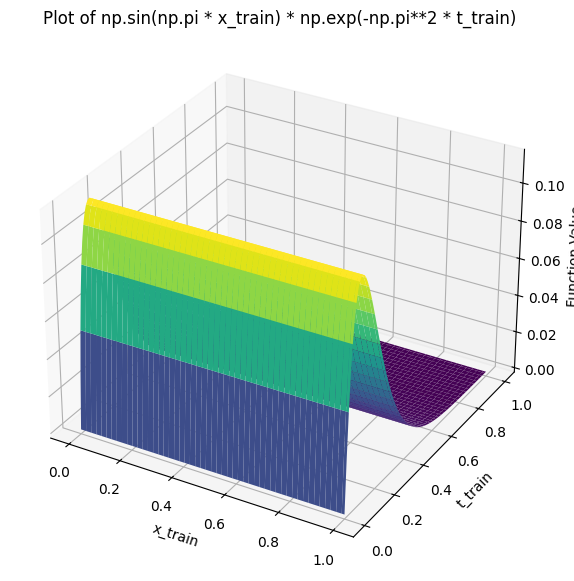

In [ ]:
# Create a 2D grid for x and t
X, T = np.meshgrid(x_test, t_test)

# Calculate the function values
Z = u_exact_test

# Plotting the 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, T, Z, cmap='viridis')

ax.set_xlabel('x_train')
ax.set_ylabel('t_train')
ax.set_zlabel('Function Value')
ax.set_title('ACTUAL')
plt.show()


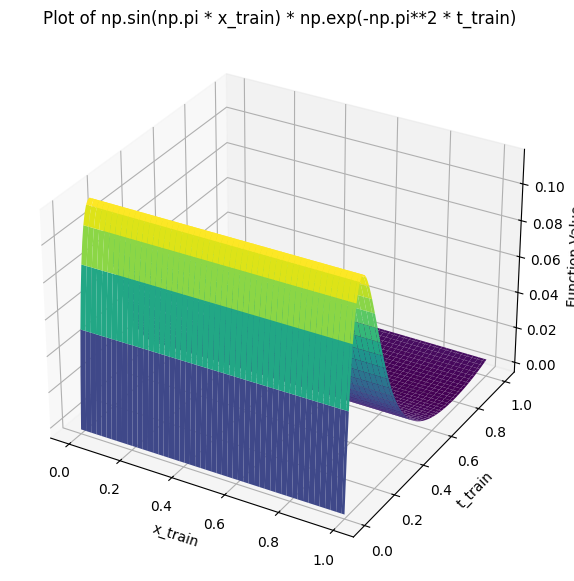

In [ ]:
# Create a 2D grid for x and t
X, T = np.meshgrid(x_test, t_test)

# Calculate the function values
Z = u_pred.numpy()

# Plotting the 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, T, Z, cmap='viridis')

ax.set_xlabel('x_train')
ax.set_ylabel('t_train')
ax.set_zlabel('Function Value')
ax.set_title('PREDICTED')
plt.show()
